<div align="center">

# Data Projects and Hackathon 3  
## Project 
Sergio Fernandez, Alessandro Mecchia 

</div>

In [ ]:
import os
import sys
import json
import time
import subprocess
import requests
from pathlib import Path

# Data Processing & Math
import pandas as pd
import numpy as np
import pyarrow as pa
import pyarrow.parquet as pq
import pyarrow.json as paj

# Machine Learning & NLP
import torch
from transformers import pipeline, AutoTokenizer, AutoModelForSeq2SeqLM
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import PCA
from langdetect import detect, DetectorFactory

# Visualization
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.graph_objects as go

# Interactive Notebook Tools
import ipywidgets as widgets
from IPython.display import display

# Ensure consistent language detection
DetectorFactory.seed = 0
import duckdb 

import gc

In [ ]:
if torch.cuda.is_available():
    print(f"GPU found: {torch.cuda.get_device_name(0)}")
    print(f"CUDA Version: {torch.version.cuda}")
else:
    print("GPU not detected. PyTorch is running on CPU.")

In [ ]:
sns.set_theme(style="whitegrid", context="talk")
plt.rcParams["figure.figsize"] = (12, 5)


## Functions 

In [ ]:
def to_python_nested(x):
    if x is None:
        return None
    if isinstance(x, float) and pd.isna(x):
        return None
    if isinstance(x, np.ndarray):
        return [to_python_nested(v) for v in x.tolist()]
    if isinstance(x, tuple):
        return [to_python_nested(v) for v in x]
    if isinstance(x, list):
        return [to_python_nested(v) for v in x]
    if isinstance(x, dict):
        return {k: to_python_nested(v) for k, v in x.items()}
    return x

def normalize_author_value(v):
    if isinstance(v, np.generic):
        v = v.item()
    if isinstance(v, float) and pd.isna(v):
        return None
    return v

def normalize_authors_cell(x):
    if x is None:
        return None
    if isinstance(x, float) and pd.isna(x):
        return None

    if isinstance(x, np.ndarray):
        x = x.tolist()
    elif isinstance(x, dict):
        x = [x]
    elif isinstance(x, tuple):
        x = list(x)
    elif not isinstance(x, list):
        return None

    out = []
    for item in x:
        if isinstance(item, np.ndarray):
            item = item.tolist()

        if not isinstance(item, dict):
            continue

        clean_item = {k: normalize_author_value(v) for k, v in item.items()}
        out.append(clean_item)

    return out if out else None

def is_empty(x):
    if x is None:
        return True
    if isinstance(x, str):
        return x.strip() == ""
    if isinstance(x, (list, tuple, set, dict)):
        return len(x) == 0
    if isinstance(x, np.ndarray):
        return x.size == 0
    return pd.isna(x)

def valid_authors_sequence(authors):
    if authors is None:
        return False
    if isinstance(authors, float) and pd.isna(authors):
        return False
    try:
        if isinstance(authors, np.ndarray):
            return authors.ndim > 0 and len(authors) > 0
        return isinstance(authors, (list, tuple)) and len(authors) > 0
    except Exception:
        return False
    
def authors_complete(authors):
    if not valid_authors_sequence(authors):
        return False

    for author in authors:
        if not isinstance(author, dict):
            return False
        if is_empty(author.get("id")) or is_empty(author.get("org")):
            return False

    return True

In [ ]:
def check_missing_column(pf, col):
    missing_count = 0
    filled_count = 0
    n = 0

    for rg in range(pf.num_row_groups):
        chunk = pf.read_row_group(rg, columns=[col]).to_pandas()
        missing_mask = chunk[col].apply(is_empty)

        missing_count += missing_mask.sum()
        filled_count += (~missing_mask).sum()
        n += len(chunk)

    print(f"{col} summary (sample of {n:,} rows):\n")
    print(f"missing : {missing_count:,}")
    print(f"filled  : {filled_count:,}")
    print(f"missing %: {missing_count / n * 100:.4f}")

In [ ]:
from concurrent.futures import ThreadPoolExecutor, as_completed

OPENALEX_REFERENCES_CACHE = Path("data/cache_openalex_references.json")
MAILTO = ""  # put your email here for polite pool

def load_cache(path):
    if path.exists():
        with open(path, "r", encoding="utf-8") as f:
            return json.load(f)
    return {}

def save_cache(path, cache):
    with open(path, "w", encoding="utf-8") as f:
        json.dump(cache, f, ensure_ascii=False)

def normalize_doi(x):
    if x is None:
        return ""
    x = str(x).strip().lower()
    return x.replace("https://doi.org/", "").replace("http://doi.org/", "").rstrip("/")

def chunked(seq, size):
    for i in range(0, len(seq), size):
        yield seq[i:i + size]

def fetch_openalex_references_batch(dois_batch, timeout=30):
    session = requests.Session()
    doi_filter = "|".join(dois_batch)

    r = session.get(
        "https://api.openalex.org/works",
        params={
            "filter": f"doi:{doi_filter}",
            "select": "doi,referenced_works",
            "per_page": len(dois_batch),
            "mailto": MAILTO,
        },
        headers={"User-Agent": "DBLP-imputation/1.0"},
        timeout=timeout,
    )
    r.raise_for_status()

    out = {}
    for work in r.json().get("results", []):
        doi = normalize_doi(work.get("doi"))
        refs = work.get("referenced_works", [])
        out[doi] = refs if refs else None
    return out

def fetch_openalex_references_parallel(dois, batch_size=50, max_workers=4, pause_s=0.05):
    results = {}
    batches = list(chunked(dois, batch_size))

    with ThreadPoolExecutor(max_workers=max_workers) as ex:
        futures = {
            ex.submit(fetch_openalex_references_batch, batch): batch
            for batch in batches
        }

        for i, fut in enumerate(as_completed(futures), start=1):
            batch = futures[fut]
            try:
                batch_result = fut.result()
                results.update(batch_result)
            except Exception as e:
                print(f"Batch failed ({len(batch)} dois): {e}")

            if i % 10 == 0 or i == len(batches):
                print(f"  batches completed: {i}/{len(batches)}")
                if pause_s > 0:
                    time.sleep(pause_s)

    return results

def impute_references_from_openalex_batch(df, batch_size=50, max_workers=4):
    cache = load_cache(OPENALEX_REFERENCES_CACHE)

    mask = df["references"].apply(is_empty) & ~df["doi"].apply(is_empty)
    target_idx = df[mask].index.tolist()
    print(f"references: rows to inspect = {len(target_idx)}")

    dois = [normalize_doi(df.at[idx, "doi"]) for idx in target_idx]
    dois = [d for d in dois if d]

    unique_missing = sorted({d for d in dois if d not in cache})
    print(f"references: DOI not in cache = {len(unique_missing)}")

    if unique_missing:
        fetched = fetch_openalex_references_parallel(
            unique_missing,
            batch_size=batch_size,
            max_workers=max_workers,
        )
        cache.update(fetched)
        save_cache(OPENALEX_REFERENCES_CACHE, cache)

    recovered = 0
    for idx in target_idx:
        doi = normalize_doi(df.at[idx, "doi"])
        refs = cache.get(doi)

        if refs and is_empty(df.at[idx, "references"]):
            df.at[idx, "references"] = refs
            recovered += 1

    print("\nImputation completed for references")
    print(f"Recovered: {recovered}/{len(target_idx)}")
    print(f"Still missing: {df['references'].apply(is_empty).sum()}")

In [ ]:
OPENALEX_ABSTRACT_CACHE = Path("data/cache_openalex_abstracts.json")
MAILTO = "" # put your email here for polite pool

def reconstruct_abstract(inverted_index):
    if not inverted_index:
        return None

    max_pos = max((max(pos) for pos in inverted_index.values() if pos), default=-1)
    if max_pos < 0:
        return None

    words = [""] * (max_pos + 1)
    for word, positions in inverted_index.items():
        for pos in positions:
            words[pos] = word

    text = " ".join(words).strip()
    return text if text else None

def fetch_openalex_abstracts_batch(dois_batch, timeout=30):
    session = requests.Session()
    doi_filter = "|".join(dois_batch)

    r = session.get(
        "https://api.openalex.org/works",
        params={
            "filter": f"doi:{doi_filter}",
            "select": "doi,abstract_inverted_index",
            "per_page": len(dois_batch),
            "mailto": MAILTO,
        },
        headers={"User-Agent": "DBLP-imputation/1.0"},
        timeout=timeout,
    )
    r.raise_for_status()

    out = {}
    for work in r.json().get("results", []):
        doi = normalize_doi(work.get("doi"))
        abstract = reconstruct_abstract(work.get("abstract_inverted_index"))
        out[doi] = abstract
    return out

def fetch_openalex_abstracts_parallel(dois, batch_size=50, max_workers=4, pause_s=0.05):
    results = {}
    batches = list(chunked(dois, batch_size))

    with ThreadPoolExecutor(max_workers=max_workers) as ex:
        futures = {
            ex.submit(fetch_openalex_abstracts_batch, batch): batch
            for batch in batches
        }

        for i, fut in enumerate(as_completed(futures), start=1):
            batch = futures[fut]
            try:
                batch_result = fut.result()
                results.update(batch_result)
            except Exception as e:
                print(f"Batch failed ({len(batch)} dois): {e}")

            if i % 10 == 0 or i == len(batches):
                print(f"  batches completed: {i}/{len(batches)}")
                if pause_s > 0:
                    time.sleep(pause_s)

    return results

def impute_abstract_from_openalex_batch(df, batch_size=50, max_workers=4):
    cache = load_cache(OPENALEX_ABSTRACT_CACHE)

    mask = df["abstract"].apply(is_empty) & ~df["doi"].apply(is_empty)
    target_idx = df[mask].index.tolist()
    print(f"abstract: rows to inspect = {len(target_idx)}")

    dois = [normalize_doi(df.at[idx, "doi"]) for idx in target_idx]
    dois = [d for d in dois if d]

    unique_missing = sorted({d for d in dois if d not in cache})
    print(f"abstract: DOI not in cache = {len(unique_missing)}")

    if unique_missing:
        fetched = fetch_openalex_abstracts_parallel(
            unique_missing,
            batch_size=batch_size,
            max_workers=max_workers,
        )
        cache.update(fetched)
        save_cache(OPENALEX_ABSTRACT_CACHE, cache)

    recovered = 0
    for idx in target_idx:
        doi = normalize_doi(df.at[idx, "doi"])
        abstract = cache.get(doi)

        if abstract and is_empty(df.at[idx, "abstract"]):
            df.at[idx, "abstract"] = abstract
            recovered += 1

    print("\nImputation completed for abstract")
    print(f"Recovered: {recovered}/{len(target_idx)}")
    print(f"Still missing: {df['abstract'].apply(is_empty).sum()}")


In [ ]:
OPENALEX_VENUE_CACHE = Path("data/cache_openalex_venue.json")
MAILTO = "" # put your email here for polite pool

def extract_venue_from_work(data):
    if not isinstance(data, dict):
        return None
    venue = data.get("primary_location", {}).get("raw_source_name")
    return venue if venue else None

def fetch_openalex_venue_batch(dois_batch, timeout=30):
    session = requests.Session()
    doi_filter = "|".join(dois_batch)

    r = session.get(
        "https://api.openalex.org/works",
        params={
            "filter": f"doi:{doi_filter}",
            "select": "doi,primary_location",
            "per_page": len(dois_batch),
            "mailto": MAILTO,
        },
        headers={"User-Agent": "DBLP-imputation/1.0"},
        timeout=timeout,
    )
    r.raise_for_status()

    out = {}
    for work in r.json().get("results", []):
        doi = normalize_doi(work.get("doi"))
        venue = extract_venue_from_work(work)
        out[doi] = venue
    return out

def fetch_openalex_venue_parallel(dois, batch_size=50, max_workers=4, pause_s=0.05):
    results = {}
    batches = list(chunked(dois, batch_size))

    with ThreadPoolExecutor(max_workers=max_workers) as ex:
        futures = {
            ex.submit(fetch_openalex_venue_batch, batch): batch
            for batch in batches
        }

        for i, fut in enumerate(as_completed(futures), start=1):
            batch = futures[fut]
            try:
                batch_result = fut.result()
                results.update(batch_result)
            except Exception as e:
                print(f"Batch failed ({len(batch)} dois): {e}")

            if i % 10 == 0 or i == len(batches):
                print(f"  batches completed: {i}/{len(batches)}")
                if pause_s > 0:
                    time.sleep(pause_s)

    return results

def impute_venue_from_openalex_batch(df, batch_size=50, max_workers=4):
    cache = load_cache(OPENALEX_VENUE_CACHE)

    mask = df["venue"].apply(is_empty) & ~df["doi"].apply(is_empty)
    target_idx = df[mask].index.tolist()
    print(f"venue: rows to inspect = {len(target_idx)}")

    dois = [normalize_doi(df.at[idx, "doi"]) for idx in target_idx]
    dois = [d for d in dois if d]

    unique_missing = sorted({d for d in dois if d not in cache})
    print(f"venue: DOI not in cache = {len(unique_missing)}")

    if unique_missing:
        fetched = fetch_openalex_venue_parallel(
            unique_missing,
            batch_size=batch_size,
            max_workers=max_workers,
        )
        cache.update(fetched)
        save_cache(OPENALEX_VENUE_CACHE, cache)

    recovered = 0
    for idx in target_idx:
        doi = normalize_doi(df.at[idx, "doi"])
        venue = cache.get(doi)

        if venue and is_empty(df.at[idx, "venue"]):
            df.at[idx, "venue"] = venue
            recovered += 1

    print("\nImputation completed for venue")
    print(f"Recovered: {recovered}/{len(target_idx)}")
    print(f"Still missing: {df['venue'].apply(is_empty).sum()}")


In [ ]:
OPENALEX_KEYWORDS_CACHE = Path("data/cache_openalex_keywords.json")
MAILTO = "" # put your email here for polite pool

def extract_keywords_from_work(data):
    if not isinstance(data, dict):
        return None

    concepts = data.get("concepts", [])
    keywords = [
        c["display_name"]
        for c in concepts
        if c.get("level", 0) >= 1 and c.get("score", 0) >= 0.3
    ]
    return keywords if keywords else None

def fetch_openalex_keywords_batch(dois_batch, timeout=30):
    session = requests.Session()
    doi_filter = "|".join(dois_batch)

    r = session.get(
        "https://api.openalex.org/works",
        params={
            "filter": f"doi:{doi_filter}",
            "select": "doi,concepts",
            "per_page": len(dois_batch),
            "mailto": MAILTO,
        },
        headers={"User-Agent": "DBLP-imputation/1.0"},
        timeout=timeout,
    )
    r.raise_for_status()

    out = {}
    for work in r.json().get("results", []):
        doi = normalize_doi(work.get("doi"))
        keywords = extract_keywords_from_work(work)
        out[doi] = keywords
    return out

def fetch_openalex_keywords_parallel(dois, batch_size=50, max_workers=4, pause_s=0.05):
    results = {}
    batches = list(chunked(dois, batch_size))

    with ThreadPoolExecutor(max_workers=max_workers) as ex:
        futures = {
            ex.submit(fetch_openalex_keywords_batch, batch): batch
            for batch in batches
        }

        for i, fut in enumerate(as_completed(futures), start=1):
            batch = futures[fut]
            try:
                batch_result = fut.result()
                results.update(batch_result)
            except Exception as e:
                print(f"Batch failed ({len(batch)} dois): {e}")

            if i % 10 == 0 or i == len(batches):
                print(f"  batches completed: {i}/{len(batches)}")
                if pause_s > 0:
                    time.sleep(pause_s)

    return results

def impute_keywords_from_openalex_batch(df, batch_size=50, max_workers=4):
    cache = load_cache(OPENALEX_KEYWORDS_CACHE)

    mask = df["keywords"].apply(is_empty) & ~df["doi"].apply(is_empty)
    target_idx = df[mask].index.tolist()
    print(f"keywords: rows to inspect = {len(target_idx)}")

    dois = [normalize_doi(df.at[idx, "doi"]) for idx in target_idx]
    dois = [d for d in dois if d]

    unique_missing = sorted({d for d in dois if d not in cache})
    print(f"keywords: DOI not in cache = {len(unique_missing)}")

    if unique_missing:
        fetched = fetch_openalex_keywords_parallel(
            unique_missing,
            batch_size=batch_size,
            max_workers=max_workers,
        )
        cache.update(fetched)
        save_cache(OPENALEX_KEYWORDS_CACHE, cache)

    recovered = 0
    for idx in target_idx:
        doi = normalize_doi(df.at[idx, "doi"])
        keywords = cache.get(doi)

        if keywords and is_empty(df.at[idx, "keywords"]):
            df.at[idx, "keywords"] = keywords
            recovered += 1

    print("\nImputation completed for keywords")
    print(f"Recovered: {recovered}/{len(target_idx)}")
    print(f"Still missing: {df['keywords'].apply(is_empty).sum()}")


In [ ]:
OPENALEX_DOC_TYPE_CACHE = Path("data/cache_openalex_doc_type.json")

def fetch_openalex_doc_type_batch(dois_batch, timeout=30):
    session = requests.Session()
    doi_filter = "|".join(dois_batch)

    r = session.get(
        "https://api.openalex.org/works",
        params={
            "filter": f"doi:{doi_filter}",
            "select": "doi,type",
            "per_page": len(dois_batch),
            "mailto": MAILTO,
        },
        headers={"User-Agent": "DBLP-imputation/1.0"},
        timeout=timeout,
    )
    r.raise_for_status()

    out = {}
    for work in r.json().get("results", []):
        doi = normalize_doi(work.get("doi"))
        doc_type = work.get("type")
        out[doi] = doc_type if doc_type else None
    return out

def fetch_openalex_doc_type_parallel(dois, batch_size=50, max_workers=4, pause_s=0.05):
    results = {}
    batches = list(chunked(dois, batch_size))

    with ThreadPoolExecutor(max_workers=max_workers) as ex:
        futures = {
            ex.submit(fetch_openalex_doc_type_batch, batch): batch
            for batch in batches
        }

        for i, fut in enumerate(as_completed(futures), start=1):
            batch = futures[fut]
            try:
                batch_result = fut.result()
                results.update(batch_result)
            except Exception as e:
                print(f"Batch failed ({len(batch)} dois): {e}")

            if i % 10 == 0 or i == len(batches):
                print(f"  batches completed: {i}/{len(batches)}")
                if pause_s > 0:
                    time.sleep(pause_s)

    return results

def impute_doc_type_from_openalex_batch(df, batch_size=50, max_workers=4):
    cache = load_cache(OPENALEX_DOC_TYPE_CACHE)

    mask = df["doc_type"].apply(is_empty) & ~df["doi"].apply(is_empty)
    target_idx = df[mask].index.tolist()
    print(f"doc_type: rows to inspect = {len(target_idx)}")

    dois = [normalize_doi(df.at[idx, "doi"]) for idx in target_idx]
    dois = [d for d in dois if d]

    unique_missing = sorted({d for d in dois if d not in cache})
    print(f"doc_type: DOI not in cache = {len(unique_missing)}")

    if unique_missing:
        fetched = fetch_openalex_doc_type_parallel(
            unique_missing,
            batch_size=batch_size,
            max_workers=max_workers,
        )
        cache.update(fetched)
        save_cache(OPENALEX_DOC_TYPE_CACHE, cache)

    recovered = 0
    for idx in target_idx:
        doi = normalize_doi(df.at[idx, "doi"])
        doc_type = cache.get(doi)

        if doc_type and is_empty(df.at[idx, "doc_type"]):
            df.at[idx, "doc_type"] = doc_type
            recovered += 1

    print("\nImputation completed for doc_type")
    print(f"Recovered: {recovered}/{len(target_idx)}")
    print(f"Still missing: {df['doc_type'].apply(is_empty).sum()}")


In [11]:
import math
import pandas as pd
import pyarrow as pa
import pyarrow.parquet as pq
from collections import defaultdict
from langdetect import detect, DetectorFactory
import yake

DetectorFactory.seed = 0

SUPPORTED_LANGS = {"en", "de", "fr", "pt", "es", "it", "zh", "ja", "ko", "ru"}

YAKE_LANG_MAP = {
    "en": "en",
    "it": "it",
    "fr": "fr",
    "de": "de",
    "es": "es",
    "pt": "pt",
    "zh": "zh",
    "ja": "ja",
    "ko": "ko",
    "ru": "ru",
}


In [ ]:
def detect_lang(row):
    parts = []
    for col in ["title", "abstract", "venue"]:
        val = row.get(col)
        if isinstance(val, str) and val.strip():
            parts.append(val.strip())

    text = " ".join(parts)

    if len(text) < 30:
        return None

    try:
        pred = detect(text)
        return pred if pred in SUPPORTED_LANGS else None
    except Exception:
        return None


In [14]:
from collections import defaultdict

def valid_authors_sequence(authors):
    if authors is None:
        return False
    if isinstance(authors, float) and pd.isna(authors):
        return False

    try:
        if isinstance(authors, np.ndarray):
            return authors.ndim > 0 and len(authors) > 0
        return isinstance(authors, (list, tuple)) and len(authors) > 0
    except Exception:
        return False


def build_author_mappings(input_path):
    pf = pq.ParquetFile(input_path)

    name_to_id = {}
    name_to_year_orgs = defaultdict(list)

    for rg in range(pf.num_row_groups):
        print(f"[authors mapping] Row group {rg + 1}/{pf.num_row_groups}")

        chunk = pf.read_row_group(rg, columns=["authors", "year"]).to_pandas()

        for _, row in chunk.iterrows():
            year = row.get("year")
            authors = row.get("authors")

            if not valid_authors_sequence(authors):
                continue

            parsed_year = None
            try:
                if year is not None and not (isinstance(year, float) and pd.isna(year)):
                    parsed_year = int(year)
            except Exception:
                parsed_year = None

            for author in authors:
                if not isinstance(author, dict):
                    continue

                name = author.get("name")
                author_id = author.get("id")
                org = author.get("org")

                if isinstance(name, str):
                    name = name.strip()

                if not name:
                    continue

                if isinstance(author_id, str) and author_id.strip() and name not in name_to_id:
                    name_to_id[name] = author_id.strip()

                if isinstance(org, str) and org.strip() and parsed_year is not None:
                    name_to_year_orgs[name].append((parsed_year, org.strip()))

    print(f"Created mapping for {len(name_to_id):,} unique author names")
    print(f"Created org history for {len(name_to_year_orgs):,} author names")

    return name_to_id, name_to_year_orgs


In [ ]:
def impute_authors_id_chunk(chunk, name_to_id):
    recovered = 0

    for idx, row in chunk.iterrows():
        authors = row.get("authors")

        if not valid_authors_sequence(authors):
            continue

        changed = False
        for author in authors:
            if not isinstance(author, dict):
                continue

            name = author.get("name")
            author_id = author.get("id")

            if isinstance(name, str):
                name = name.strip()

            if not author_id and name and name in name_to_id:
                author["id"] = name_to_id[name]
                recovered += 1
                changed = True

        if changed:
            chunk.at[idx, "authors"] = authors

    print(f"Recovered {recovered:,} author IDs")
    return chunk


In [16]:
def impute_authors_org_chunk(chunk, name_to_year_orgs, max_year_diff=1):
    recovered = 0

    for idx, row in chunk.iterrows():
        year = row.get("year")
        authors = row.get("authors")

        if not valid_authors_sequence(authors):
            continue

        try:
            if year is None or (isinstance(year, float) and pd.isna(year)):
                continue
            year = int(year)
        except Exception:
            continue

        changed = False
        for author in authors:
            if not isinstance(author, dict):
                continue

            name = author.get("name")
            org = author.get("org")

            if isinstance(name, str):
                name = name.strip()

            if org or not name:
                continue

            candidates = name_to_year_orgs.get(name)
            if not candidates:
                continue

            best_org = None
            best_distance = float("inf")

            for cand_year, cand_org in candidates:
                distance = abs(cand_year - year)
                if distance <= max_year_diff and distance < best_distance:
                    best_org = cand_org
                    best_distance = distance
                    if distance == 0:
                        break

            if best_org:
                author["org"] = best_org
                recovered += 1
                changed = True

        if changed:
            chunk.at[idx, "authors"] = authors

    print(f"Recovered {recovered:,} author ORGs")
    return chunk


## 1. Data Creation

###  1.2. Parquet Creation 

da eseguire una sola volta 

In [10]:
DATA_DIR = Path("data")
SOURCE_PATH = DATA_DIR / "DBLP-Citation-network-V18.jsonl"
TARGET_PATH = DATA_DIR / "DBLP-Citation-network-V18.parquet"
BLOCK_SIZE = 64 * 1024 * 1024  

if not SOURCE_PATH.exists():
    raise FileNotFoundError(f"File non trovato: {SOURCE_PATH}")

if pa.Codec.is_available("zstd"):
    COMPRESSION = "zstd"
elif pa.Codec.is_available("snappy"):
    COMPRESSION = "snappy"
else:
    COMPRESSION = None

print(f"Input : {SOURCE_PATH} ({SOURCE_PATH.stat().st_size / 1024**3:.2f} GiB)")
print(f"Output: {TARGET_PATH}")
print(f"Compressione: {COMPRESSION}")
print(f"Block size: {BLOCK_SIZE / 1024**2:.0f} MiB")

In [11]:
DROP_COLS = {"page_start", "page_end", "volume", "issue", "issn", "isbn", "url"}

if TARGET_PATH.exists():
    print(f"Parquet already exists, skipping conversion.")
else:
    reader = paj.open_json(
        SOURCE_PATH,
        read_options=paj.ReadOptions(block_size=BLOCK_SIZE),
    )

    writer = None
    rows_written = 0
    batches_written = 0
    started_at = time.perf_counter()

    try:
        while True:
            try:
                batch = reader.read_next_batch()
            except StopIteration:
                break

            keep_cols = [name for name in batch.schema.names if name not in DROP_COLS]
            batch = batch.select(keep_cols)

            if writer is None:
                writer = pq.ParquetWriter(
                    TARGET_PATH,
                    batch.schema,
                    compression=COMPRESSION,
                )

            writer.write_batch(batch)
            rows_written += batch.num_rows
            batches_written += 1

            if batches_written % 25 == 0:
                elapsed = time.perf_counter() - started_at
                print(f"Batch: {batches_written:>5} | Rows: {rows_written:>12,} | Elapsed: {elapsed:>8.1f}s")

        if writer is None:
            raise RuntimeError("JSONL file seems empty: no batch read.")
    finally:
        reader.close()
        if writer is not None:
            writer.close()

    elapsed = time.perf_counter() - started_at
    print(f"Conversion completed in {elapsed:.1f}s")
    print(f"Rows written : {rows_written:,}")
    print(f"JSONL size   : {SOURCE_PATH.stat().st_size / 1024**3:.2f} GiB")
    print(f"Parquet size : {TARGET_PATH.stat().st_size / 1024**3:.2f} GiB")

Parquet already exists, skipping conversion.


### 1.2 Data Creation with DuckDB

Prima di lavorare su batch o sample, facciamo profiling e data quality sull'intero dataset direttamente sul parquet via DuckDB. In questo modo i conteggi dei missing, le distribuzioni per anno e la selezione dei candidati per imputazione sono globali e non dipendono dal sample da 10k record.

In [ ]:
PARQUET_PATH = Path("data/DBLP-Citation-network-V18.parquet")


con = duckdb.connect(":memory:")

# con = duckdb.connect(r"C:\Users\ms\Desktop\dblp.duckdb")

con.execute("PRAGMA threads=4;")
con.execute("PRAGMA enable_progress_bar;")

parquet_str = PARQUET_PATH.as_posix()

con.execute(f"""
    CREATE OR REPLACE VIEW papers AS
    SELECT *
    FROM read_parquet('{parquet_str}');
""")

In [ ]:
display(con.execute("SELECT * FROM papers LIMIT 5").fetchdf())

In [ ]:
# PROFILE_DB_PATH = DATA_DIR / "dblp_profiling.duckdb"

# con_full = duckdb.connect(PROFILE_DB_PATH.as_posix())
# con_full.execute("PRAGMA threads=4;")
# con_full.execute("PRAGMA enable_progress_bar;")

# con_full.execute(f"""
#     CREATE OR REPLACE VIEW papers_full AS
#     SELECT *
#     FROM read_parquet('{parquet_str}');
# """)

# total_rows_full = con_full.execute("SELECT COUNT(*) FROM papers_full").fetchone()[0]
# print(f"Profiling DB: {PROFILE_DB_PATH}")
# print(f"Total rows available in DuckDB: {total_rows_full:,}")

## 2. Data Exploration  

In [ ]:
# pf = pq.ParquetFile(r"data/DBLP-Citation-network-V18.parquet")

# print(f"Total rows   : {pf.metadata.num_rows:,}")
# print(f"Columns      : {pf.metadata.num_columns}")
# print(f"Row groups   : {pf.metadata.num_row_groups}")

In [ ]:
total_rows = con.execute("""
    SELECT COUNT(*)
    FROM papers
""").fetchone()[0]

n_columns = con.execute("""
    DESCRIBE SELECT * FROM papers
""").fetchdf().shape[0]

row_groups = con.execute(f"""
    SELECT COUNT(DISTINCT row_group_id)
    FROM parquet_metadata('{parquet_str}')
""").fetchone()[0]

print(f"Total rows   : {total_rows:,}")
print(f"Columns      : {n_columns}")
print(f"Row groups   : {row_groups}")


In [ ]:
schema_df = con.execute("""
    DESCRIBE SELECT * FROM papers
""").fetchdf()

for i, name in enumerate(schema_df["column_name"]):
    print(f"{i}. {name}")


In [ ]:
schema_df = con.execute("""
    DESCRIBE SELECT * FROM papers
""").fetchdf()

columns = schema_df["column_name"].tolist()

dropdown = widgets.Dropdown(options=columns, description="Colonna:")
output = widgets.Output()

def on_change(change):
    if change["type"] == "change" and change["name"] == "value":
        col = change["new"]
        with output:
            output.clear_output()
            df = con.execute(f'''
                SELECT "{col}"
                FROM papers
                LIMIT 10
            ''').fetchdf()
            display(df)

dropdown.observe(on_change)

display(dropdown, output)

In [ ]:
paper = con.execute("""
    SELECT *
    FROM papers
    LIMIT 1
""").fetchdf().iloc[0]

for col, val in paper.items():
    print(f"{col:15}: {val}")

### 2.1. Data Selection

In [ ]:
con.execute("""
    CREATE OR REPLACE VIEW papers_profile_base AS
    SELECT
        *,
        CASE WHEN title IS NULL OR TRIM(CAST(title AS VARCHAR)) = '' THEN TRUE ELSE FALSE END AS flag_missing_title,
        CASE WHEN abstract IS NULL OR TRIM(CAST(abstract AS VARCHAR)) = '' THEN TRUE ELSE FALSE END AS flag_missing_abstract,
        CASE WHEN doi IS NULL OR TRIM(CAST(doi AS VARCHAR)) = '' THEN TRUE ELSE FALSE END AS flag_missing_doi,
        CASE WHEN lang IS NULL OR TRIM(CAST(lang AS VARCHAR)) = '' THEN TRUE ELSE FALSE END AS flag_missing_lang,
        CASE WHEN venue IS NULL OR TRIM(CAST(venue AS VARCHAR)) = '' THEN TRUE ELSE FALSE END AS flag_missing_venue,
        CASE WHEN doc_type IS NULL OR TRIM(CAST(doc_type AS VARCHAR)) = '' THEN TRUE ELSE FALSE END AS flag_missing_doc_type,
        CASE WHEN COALESCE(array_length(keywords), 0) = 0 THEN TRUE ELSE FALSE END AS flag_missing_keywords,
        CASE WHEN COALESCE(array_length("references"), 0) = 0 THEN TRUE ELSE FALSE END AS flag_missing_references,
        CASE WHEN COALESCE(array_length(authors), 0) = 0 THEN TRUE ELSE FALSE END AS flag_missing_authors,
        CASE WHEN TRY_CAST(year AS INTEGER) IS NULL THEN TRUE ELSE FALSE END AS flag_year_missing,
        TRY_CAST(year AS INTEGER) AS year_int

    FROM papers
""")


### 2.1.1. Missing Values

In [ ]:
missing_summary = con.execute("""
    SELECT * FROM (
        SELECT 'title' AS feature, SUM(CAST(flag_missing_title AS INTEGER)) AS count_rows FROM papers_profile_base
        UNION ALL
        SELECT 'abstract', SUM(CAST(flag_missing_abstract AS INTEGER)) FROM papers_profile_base
        UNION ALL
        SELECT 'doi', SUM(CAST(flag_missing_doi AS INTEGER)) FROM papers_profile_base
        UNION ALL
        SELECT 'lang', SUM(CAST(flag_missing_lang AS INTEGER)) FROM papers_profile_base
        UNION ALL
        SELECT 'venue', SUM(CAST(flag_missing_venue AS INTEGER)) FROM papers_profile_base
        UNION ALL
        SELECT 'doc_type', SUM(CAST(flag_missing_doc_type AS INTEGER)) FROM papers_profile_base
        UNION ALL
        SELECT 'keywords', SUM(CAST(flag_missing_keywords AS INTEGER)) FROM papers_profile_base
        UNION ALL
        SELECT 'references', SUM(CAST(flag_missing_references AS INTEGER)) FROM papers_profile_base
        UNION ALL
        SELECT 'authors', SUM(CAST(flag_missing_authors AS INTEGER)) FROM papers_profile_base
        UNION ALL
        SELECT 'year', SUM(CAST(flag_year_missing AS INTEGER)) FROM papers_profile_base
    )
    ORDER BY count_rows DESC
""").fetchdf()

total_rows = con.execute("SELECT COUNT(*) FROM papers_profile_base").fetchone()[0]
missing_summary["pct_rows"] = missing_summary["count_rows"] / total_rows * 100
missing_summary

In [ ]:
plt.figure(figsize=(14, 7))
ax = sns.barplot(data=missing_summary, x="feature", y="pct_rows", color="#C44E52", width=0.7)

plt.title("Missing values by feature", fontsize=16, fontweight='bold', pad=20)
plt.xlabel("Feature", fontsize=13, fontweight='bold')
plt.ylabel("Missing (%)", fontsize=13, fontweight='bold')

for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', padding=5, fontsize=11, fontweight='bold')

plt.xticks(rotation=45, ha='right', fontsize=11)
plt.yticks(fontsize=11)

ax.grid(axis='y', alpha=0.3, linestyle='--', linewidth=0.7)
ax.set_axisbelow(True)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('#CCCCCC')
ax.spines['bottom'].set_color('#CCCCCC')

plt.tight_layout()
plt.show()

In [ ]:
authors_missing_summary = con.execute("""
WITH authors_exploded AS (
    SELECT
        p.id AS paper_id,
        a.author AS author
    FROM papers_profile_base p
    CROSS JOIN UNNEST(p.authors) AS a(author)
)
SELECT
    COUNT(*) AS total_author_rows,
    SUM(CASE WHEN author.id IS NULL OR TRIM(CAST(author.id AS VARCHAR)) = '' THEN 1 ELSE 0 END) AS missing_author_id,
    SUM(CASE WHEN author.name IS NULL OR TRIM(CAST(author.name AS VARCHAR)) = '' THEN 1 ELSE 0 END) AS missing_author_name,
    SUM(CASE WHEN author.org IS NULL OR TRIM(CAST(author.org AS VARCHAR)) = '' THEN 1 ELSE 0 END) AS missing_author_org
FROM authors_exploded
""").fetchdf()

display(authors_missing_summary)

In [ ]:
missing_by_year = con.execute("""
    SELECT
        year_int AS year,
        COUNT(*) AS n_papers,
        SUM(CAST(flag_missing_abstract AS INTEGER)) AS missing_abstract,
        SUM(CAST(flag_missing_doi AS INTEGER)) AS missing_doi,
        SUM(CAST(flag_missing_venue AS INTEGER)) AS missing_venue,
        SUM(CAST(flag_missing_doc_type AS INTEGER)) AS missing_doc_type,
        SUM(CAST(flag_missing_keywords AS INTEGER)) AS missing_keywords,
        SUM(CAST(flag_missing_references AS INTEGER)) AS missing_references
    FROM papers_profile_base
    WHERE year_int IS NOT NULL
    GROUP BY 1
    ORDER BY 1
""").fetchdf()

display(missing_by_year.head(5))

escludiamo gli anni fino a 1990 al 2027 non incluso e siccome vogliamo imputare abstract e reference con doi, droppiamo anche subito i paper che hanno missing DOI e una delle due features.

In [ ]:
con.execute("""
CREATE OR REPLACE VIEW papers_scope AS
SELECT *
FROM papers_profile_base
WHERE year_int > 1990
  AND year_int < 2027
  AND NOT (
      flag_missing_doi
      AND (flag_missing_abstract OR flag_missing_references)
  )
""")

In [ ]:
missing_counts_query = con.execute("""
WITH missing_per_paper AS (
    SELECT
        id,
        CAST(flag_missing_title AS INTEGER) +
        CAST(flag_missing_abstract AS INTEGER) +
        CAST(flag_missing_doi AS INTEGER) +
        CAST(flag_missing_lang AS INTEGER) +
        CAST(flag_missing_venue AS INTEGER) +
        CAST(flag_missing_doc_type AS INTEGER) +
        CAST(flag_missing_keywords AS INTEGER) +
        CAST(flag_missing_references AS INTEGER) +
        CAST(flag_missing_authors AS INTEGER) +
        CAST(flag_year_missing AS INTEGER) AS num_missing
    FROM papers_scope
)
SELECT
    num_missing,
    COUNT(*) AS count_papers
FROM missing_per_paper
GROUP BY num_missing
ORDER BY num_missing
""").fetchdf()


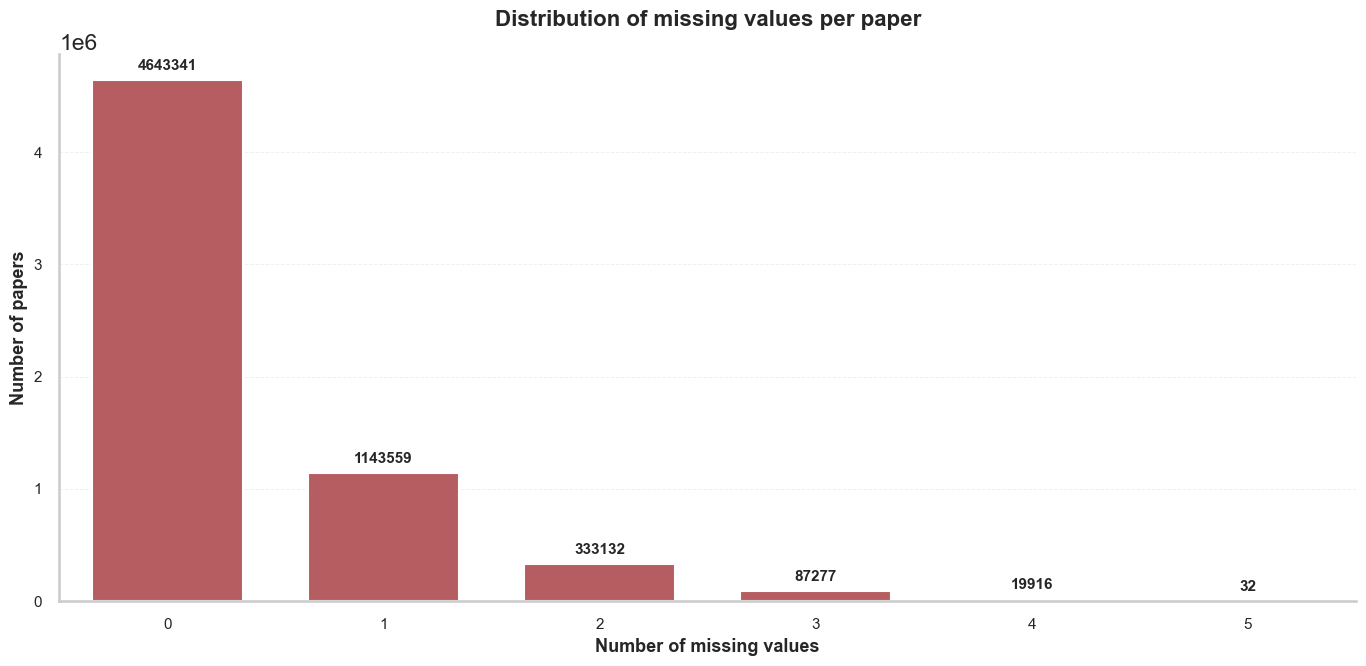

In [28]:
plt.figure(figsize=(14, 7))
ax = sns.barplot(data=missing_counts_query, x="num_missing", y="count_papers", color="#C44E52", width=0.7)

plt.title("Distribution of missing values per paper", fontsize=16, fontweight='bold', pad=20)
plt.xlabel("Number of missing values", fontsize=13, fontweight='bold')
plt.ylabel("Number of papers", fontsize=13, fontweight='bold')

missing_summary_scope["pct_rows"] = missing_summary_scope["count_rows"] / total_rows_scope * 100
display(missing_summary_scope)

plt.figure(figsize=(10, 6))
sns.barplot(data=missing_summary_scope, x="pct_rows", y="feature", color="#C44E52")
plt.title("Missing values by feature in filtered corpus")
plt.xlabel("Missing (%)")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

per risparmiare spazio droppiamo subito paper con missing importanti >= 2

In [29]:
con.execute("""
CREATE OR REPLACE VIEW papers_working AS
SELECT *
FROM (
    SELECT
        *,
        (
            CAST(flag_missing_title AS INTEGER) +
            CAST(flag_missing_abstract AS INTEGER) +
            CAST(flag_missing_lang AS INTEGER) +
            CAST(flag_missing_venue AS INTEGER) +
            CAST(flag_missing_doc_type AS INTEGER) +
            CAST(flag_missing_keywords AS INTEGER) +
            CAST(flag_missing_references AS INTEGER) +
            CAST(flag_missing_authors AS INTEGER) +
            CAST(flag_year_missing AS INTEGER)
        ) AS num_missing
    FROM papers_scope
) t
WHERE num_missing <= 1
""")

In [30]:
con.execute("""
SELECT
    COUNT(*) AS total_papers,
    SUM(CAST(flag_missing_abstract AS INTEGER)) AS missing_abstract,
    SUM(CAST(flag_missing_references AS INTEGER)) AS missing_references,
FROM papers_working
""").fetchdf()

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,total_papers,missing_abstract,missing_references
0,5915577,11700.0,477657.0


In [ ]:
missing_by_year = con.execute("""
    SELECT
        year_int AS year,
        SUM(CAST(flag_missing_abstract AS INTEGER)) AS abstract,
        SUM(CAST(flag_missing_doi AS INTEGER)) AS doi,
        SUM(CAST(flag_missing_venue AS INTEGER)) AS venue,
        SUM(CAST(flag_missing_doc_type AS INTEGER)) AS doc_type,
        SUM(CAST(flag_missing_keywords AS INTEGER)) AS keywords,
        SUM(CAST(flag_missing_references AS INTEGER)) AS "references"
    FROM papers_working
    GROUP BY 1
    ORDER BY 1
""").fetchdf()

missing_by_year = missing_by_year.set_index("year")

missing_by_year.plot(
    kind="bar",
    stacked=True,
    figsize=(16, 7),
    colormap="tab20"
)

plt.title("Missing values by year and feature")
plt.xlabel("Year")
plt.ylabel("Missing count")
plt.tight_layout()
plt.show()

In [ ]:
MAX_OPENALEX_CALLS = 90000

budget_df = con.execute("""
    SELECT
        COUNT(*) FILTER (WHERE flag_missing_abstract) AS n_missing_abstract,
        COUNT(*) FILTER (WHERE flag_missing_references) AS n_missing_references
    FROM papers_working
""").fetchdf()

n_missing_abstract = int(budget_df.loc[0, "n_missing_abstract"])
n_missing_references = int(budget_df.loc[0, "n_missing_references"])
ref_budget = max(0, MAX_OPENALEX_CALLS - n_missing_abstract)

print({
    "missing_abstract_all": n_missing_abstract,
    "missing_references_pool": n_missing_references,
    "reference_sample_budget": ref_budget
})


In [ ]:
segment_summary = con.execute(f"""
SELECT
    paper_segment,
    COUNT(*) AS n_papers,
    SUM(CASE WHEN NOT flag_missing_abstract THEN 1 ELSE 0 END) AS has_abstract,
    SUM(CASE WHEN NOT flag_missing_references THEN 1 ELSE 0 END) AS has_references,
    SUM(CASE WHEN NOT flag_missing_doi THEN 1 ELSE 0 END) AS has_doi,
    SUM(CASE WHEN COALESCE(array_length("references"), 0) >= {MIN_REFERENCES_RECOVERABLE} THEN 1 ELSE 0 END) AS refs_ge_threshold
FROM papers_record_quality_preimputation
GROUP BY 1
""").fetchdf()

In [ ]:
ref_year_counts = con.execute("""
    SELECT
        year_int AS year,
        COUNT(*) AS n_year
    FROM papers_working
    WHERE flag_missing_references
      AND NOT flag_missing_abstract
    GROUP BY 1
    ORDER BY 1
""").fetchdf()

if len(ref_year_counts) > 0 and ref_budget > 0:
    ref_year_counts["quota_float"] = (
        ref_year_counts["n_year"] / ref_year_counts["n_year"].sum() * ref_budget
    )
    ref_year_counts["k"] = ref_year_counts["quota_float"].astype(int)

    remaining = ref_budget - int(ref_year_counts["k"].sum())
    if remaining > 0:
        ref_year_counts["frac"] = ref_year_counts["quota_float"] - ref_year_counts["k"]
        extra_idx = ref_year_counts.nlargest(remaining, "frac").index
        ref_year_counts.loc[extra_idx, "k"] += 1
else:
    ref_year_counts["quota_float"] = 0.0
    ref_year_counts["k"] = 0

ref_alloc = ref_year_counts[["year", "k"]].copy()

con.register("ref_alloc_df", ref_alloc)


In [45]:
we keep only good and recoverable

In [ ]:
con.execute("""
CREATE OR REPLACE TABLE papers_final_ids AS
WITH ref_ranked AS (
    SELECT
        p.id,
        p.year_int,
        ROW_NUMBER() OVER (
            PARTITION BY p.year_int
            ORDER BY random()
        ) AS rn
    FROM papers_working p
    WHERE p.flag_missing_references
      AND NOT p.flag_missing_abstract
),
ref_sample AS (
    SELECT r.id
    FROM ref_ranked r
    JOIN ref_alloc_df a
      ON r.year_int = a.year
    WHERE r.rn <= a.k
)
SELECT p.id
FROM papers_working p
LEFT JOIN ref_sample s
  ON p.id = s.id
WHERE
    NOT p.flag_missing_references
    OR s.id IS NOT NULL
""")

In [46]:
con.execute("""
CREATE OR REPLACE VIEW papers_final_original_filtered AS
SELECT p.*
FROM papers p
JOIN papers_final_ids f
  ON p.id = f.id
""")


crea il parquet finale

In [ ]:
output_path = "data/first_dataset.parquet"

if Path(output_path).exists() or Path("data/final_dataset.parquet").exists() or Path("data/dataset.parquet").exists():
    print(f"already exists: {output_path}")
else:
    con.execute(f"""
    COPY papers_final_original_filtered
    TO '{output_path}'
    (FORMAT PARQUET)
    """)

    print("saved:", output_path)

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

saved: data/final_dataset.parquet


spiegare che ci interessa imputare solo le variabili che pensiamo possano essere utili per predirre il numero di citazioni o se un paper cita un'altro, ma prima potrebbe essere utile analizzare la distribuzione nei anni dei missing value.

In [ ]:
# pf = pq.ParquetFile(r"data/first_dataset.parquet")

# print(f"Total rows   : {pf.metadata.num_rows:,}")
# print(f"Columns      : {pf.metadata.num_columns}")
# print(f"Row groups   : {pf.metadata.num_row_groups}")

Total rows   : 5,516,220
Columns      : 14
Row groups   : 46


#### 1. Abstract, References, Venue and Doc_Type Imputation

In [ ]:
input_path = "data/first_dataset.parquet"
output_path = "data/middle_dataset.parquet"

if Path(output_path).exists() or Path("data/final_dataset.parquet").exists() or Path("data/dataset.parquet").exists():
    print(f"already exists: {output_path}")
else:
    pf = pq.ParquetFile(input_path)
    writer = None

    try:
        for rg in range(pf.num_row_groups):
            print(f"\n[openalex] Row group {rg + 1}/{pf.num_row_groups}")

            chunk = pf.read_row_group(rg).to_pandas()

            impute_abstract_from_openalex_batch(
                chunk,
                batch_size=50,
                max_workers=4,
            )

            impute_references_from_openalex_batch(
                chunk,
                batch_size=50,
                max_workers=4,
            )

            impute_keywords_from_openalex_batch(
                chunk,
                batch_size=50,
                max_workers=4,
            )

            impute_venue_from_openalex_batch(
                chunk,
                batch_size=50,
                max_workers=4,
            )

            impute_doc_type_from_openalex_batch(
                chunk,
                batch_size=50,
                max_workers=4,
            )

            table = pa.Table.from_pandas(chunk, preserve_index=False)

            if writer is None:
                writer = pq.ParquetWriter(output_path, table.schema)

            writer.write_table(table)

    finally:
        if writer is not None:
            writer.close()

    print(f"saved: {output_path}")


[openalex] Row group 1/46
abstract: rows to inspect = 277
abstract: DOI not in cache = 8
  batches completed: 1/1

Imputation completed for abstract
Recovered: 56/277
Still missing: 221
references: rows to inspect = 1797
references: DOI not in cache = 28
  batches completed: 1/1

Imputation completed for references
Recovered: 1376/1797
Still missing: 421
keywords: rows to inspect = 9037
keywords: DOI not in cache = 9037
  batches completed: 10/181
  batches completed: 20/181
  batches completed: 30/181
  batches completed: 40/181
  batches completed: 50/181
  batches completed: 60/181
  batches completed: 70/181
  batches completed: 80/181
  batches completed: 90/181
  batches completed: 100/181
  batches completed: 110/181
  batches completed: 120/181
  batches completed: 130/181
  batches completed: 140/181
  batches completed: 150/181
  batches completed: 160/181
  batches completed: 170/181
  batches completed: 180/181
  batches completed: 181/181

Imputation completed for keyword

In [19]:
# clean ram
for var_name in ["pf", "chunk", "table", "writer"]:
    if var_name in globals():
        del globals()[var_name]

gc.collect()

0

#### 2. Lang and Authors imputation

In [20]:
input_path = "data/middle_dataset.parquet"
output_path = "data/final_dataset.parquet"

if Path(output_path).exists() or Path("data/dataset.parquet").exists():
    print(f"already exists: {output_path}")
else:

    name_to_id, name_to_year_orgs = build_author_mappings(input_path)

    pf = pq.ParquetFile(input_path)
    writer = None

    try:
        for rg in range(pf.num_row_groups):
            print(f"\n[local imputation] Row group {rg + 1}/{pf.num_row_groups}")

            chunk = pf.read_row_group(rg).to_pandas()

            missing_lang_mask = chunk["lang"].apply(is_empty)
            chunk.loc[missing_lang_mask, "lang"] = (
                chunk.loc[missing_lang_mask].apply(detect_lang, axis=1)
            )


            chunk = impute_authors_id_chunk(chunk, name_to_id)
            chunk = impute_authors_org_chunk(chunk, name_to_year_orgs, max_year_diff=1)

            for col in ["authors", "keywords", "references", "url"]:
                if col in chunk.columns:
                    chunk[col] = chunk[col].apply(to_python_nested)

            chunk["authors"] = chunk["authors"].apply(normalize_authors_cell)

            table = pa.Table.from_pandas(chunk, preserve_index=False)

            if writer is None:
                writer = pq.ParquetWriter(output_path, table.schema)

            writer.write_table(table)

    finally:
        if writer is not None:
            writer.close()

    print(f"saved: {output_path}")

[authors mapping] Row group 1/46
[authors mapping] Row group 2/46
[authors mapping] Row group 3/46
[authors mapping] Row group 4/46
[authors mapping] Row group 5/46
[authors mapping] Row group 6/46
[authors mapping] Row group 7/46
[authors mapping] Row group 8/46
[authors mapping] Row group 9/46
[authors mapping] Row group 10/46
[authors mapping] Row group 11/46
[authors mapping] Row group 12/46
[authors mapping] Row group 13/46
[authors mapping] Row group 14/46
[authors mapping] Row group 15/46
[authors mapping] Row group 16/46
[authors mapping] Row group 17/46
[authors mapping] Row group 18/46
[authors mapping] Row group 19/46
[authors mapping] Row group 20/46
[authors mapping] Row group 21/46
[authors mapping] Row group 22/46
[authors mapping] Row group 23/46
[authors mapping] Row group 24/46
[authors mapping] Row group 25/46
[authors mapping] Row group 26/46
[authors mapping] Row group 27/46
[authors mapping] Row group 28/46
[authors mapping] Row group 29/46
[authors mapping] Row g

In [21]:
# clean ram
import gc

for var_name in ["name_to_id", "name_to_year_orgs", "pf", "chunk", "table", "writer"]:
    if var_name in globals():
        del globals()[var_name]

gc.collect()

0

## Analisi post imputazione da qui in avanti

In [22]:
input_path = "data/final_dataset.parquet"
pf = pq.ParquetFile(input_path)

In [23]:
from collections import Counter
lang_counter = Counter()
n = 0

for rg in range(pf.num_row_groups):
    chunk = pf.read_row_group(rg, columns=["lang"]).to_pandas()

    for val in chunk["lang"]:
        key = "(null)" if is_empty(val) else val
        lang_counter[key] += 1

    n += len(chunk)

lang_counts = pd.Series(lang_counter).sort_values(ascending=False)

print(f"Unique values of 'lang' (sample of {n:,} rows):\n")
print(lang_counts)

Unique values of 'lang' (sample of 5,516,220 rows):

en        5502660
de           6923
fr           2485
pt           1340
zh           1339
es            913
it            120
tr             84
da             69
nl             39
ru             27
cs             25
pl             23
(null)         18
no             17
et             16
ro             16
sv             12
ca             12
gl             11
eu              9
fi              6
af              6
tl              4
nb              4
sk              4
sl              4
lt              4
id              3
nn              3
hu              3
mt              3
rw              2
cy              2
ko              2
az              2
lv              2
zh_cht          1
oc              1
la              1
vi              1
ja              1
uk              1
eo              1
el              1
dtype: int64


In [24]:
check_missing_column(pf, "abstract")

abstract summary (sample of 5,516,220 rows):

missing : 9,239
filled  : 5,506,981
missing %: 0.1675


In [25]:
check_missing_column(pf, "references")


references summary (sample of 5,516,220 rows):

missing : 18,123
filled  : 5,498,097
missing %: 0.3285


In [26]:
check_missing_column(pf, "keywords")

keywords summary (sample of 5,516,220 rows):

missing : 129,892
filled  : 5,386,328
missing %: 2.3547


In [27]:
check_missing_column(pf, "doc_type")

doc_type summary (sample of 5,516,220 rows):

missing : 57
filled  : 5,516,163
missing %: 0.0010


In [28]:
check_missing_column(pf, "venue")

venue summary (sample of 5,516,220 rows):

missing : 2,407
filled  : 5,513,813
missing %: 0.0436


In [30]:
missing_authors_id = 0
missing_authors_org = 0
total_authors = 0
papers_with_no_authors = 0

for rg in range(pf.num_row_groups):
    chunk = pf.read_row_group(rg, columns=["authors"]).to_pandas()

    for authors in chunk["authors"]:
        if not valid_authors_sequence(authors):
            papers_with_no_authors += 1
            continue

        for author in authors:
            if not isinstance(author, dict):
                continue

            total_authors += 1

            if is_empty(author.get("id")):
                missing_authors_id += 1

            if is_empty(author.get("org")):
                missing_authors_org += 1

print(f"Authors summary:\n")
print(f"total authors         : {total_authors:,}")
print(f"missing authors.id    : {missing_authors_id:,}")
print(f"missing authors.org   : {missing_authors_org:,}")
print(f"papers with no authors: {papers_with_no_authors:,}")

if total_authors > 0:
    print(f"missing authors.id %  : {missing_authors_id / total_authors * 100:.4f}")
    print(f"missing authors.org % : {missing_authors_org / total_authors * 100:.4f}")

Authors summary:

total authors         : 19,417,388
missing authors.id    : 846,944
missing authors.org   : 693,418
papers with no authors: 61,406
missing authors.id %  : 4.3618
missing authors.org % : 3.5711


abbiamo imputato il piu possibile, droppiamo tutti i missing che sono rimasti e lavoriamo con il dataset finale da qui in avanti

In [3]:
def drop_missing(input_path, output_path, required_cols):
    if Path(output_path).exists():
        print(f"already exists: {output_path}")
        return

    pf = pq.ParquetFile(input_path)
    writer = None
    kept_rows = 0
    dropped_rows = 0

    try:
        for rg in range(pf.num_row_groups):
            print(f"\n[filter] Row group {rg + 1}/{pf.num_row_groups}")

            chunk = pf.read_row_group(rg).to_pandas()

            mask = pd.Series(True, index=chunk.index)

            for col in required_cols:
                mask &= ~chunk[col].apply(is_empty)

            # per authors: tieni solo paper con una lista autori valida e non vuota
            mask &= chunk["authors"].apply(valid_authors_sequence)

            kept_rows += int(mask.sum())
            dropped_rows += int((~mask).sum())

            chunk = chunk.loc[mask].copy()

            if len(chunk) == 0:
                continue

            table = pa.Table.from_pandas(chunk, preserve_index=False)

            if writer is None:
                writer = pq.ParquetWriter(output_path, table.schema)

            writer.write_table(table)

    finally:
        if writer is not None:
            writer.close()

In [11]:
required_cols = [
    "id",
    "title",
    "abstract",
    "year",
    "lang",
    "keywords",
    "references",
    "doi",
    "venue",
    "doc_type",
]

drop_missing(
    input_path="data/final_dataset.parquet",
    output_path="data/dataset.parquet",
    required_cols=required_cols,
)


[filter] Row group 1/46

[filter] Row group 2/46

[filter] Row group 3/46

[filter] Row group 4/46

[filter] Row group 5/46

[filter] Row group 6/46

[filter] Row group 7/46

[filter] Row group 8/46

[filter] Row group 9/46

[filter] Row group 10/46

[filter] Row group 11/46

[filter] Row group 12/46

[filter] Row group 13/46

[filter] Row group 14/46

[filter] Row group 15/46

[filter] Row group 16/46

[filter] Row group 17/46

[filter] Row group 18/46

[filter] Row group 19/46

[filter] Row group 20/46

[filter] Row group 21/46

[filter] Row group 22/46

[filter] Row group 23/46

[filter] Row group 24/46

[filter] Row group 25/46

[filter] Row group 26/46

[filter] Row group 27/46

[filter] Row group 28/46

[filter] Row group 29/46

[filter] Row group 30/46

[filter] Row group 31/46

[filter] Row group 32/46

[filter] Row group 33/46

[filter] Row group 34/46

[filter] Row group 35/46

[filter] Row group 36/46

[filter] Row group 37/46

[filter] Row group 38/46

[filter] Row group 3

## Data Visualizzation 

In [ ]:
pf = pq.ParquetFile("data/dataset.parquet")

parts = []
for batch in pf.iter_batches(batch_size=100_000):
    df_batch = batch.to_pandas()
    parts.append(df_batch.sample(min(5000, len(df_batch)), random_state=42))

df = pd.concat(parts, ignore_index=True)

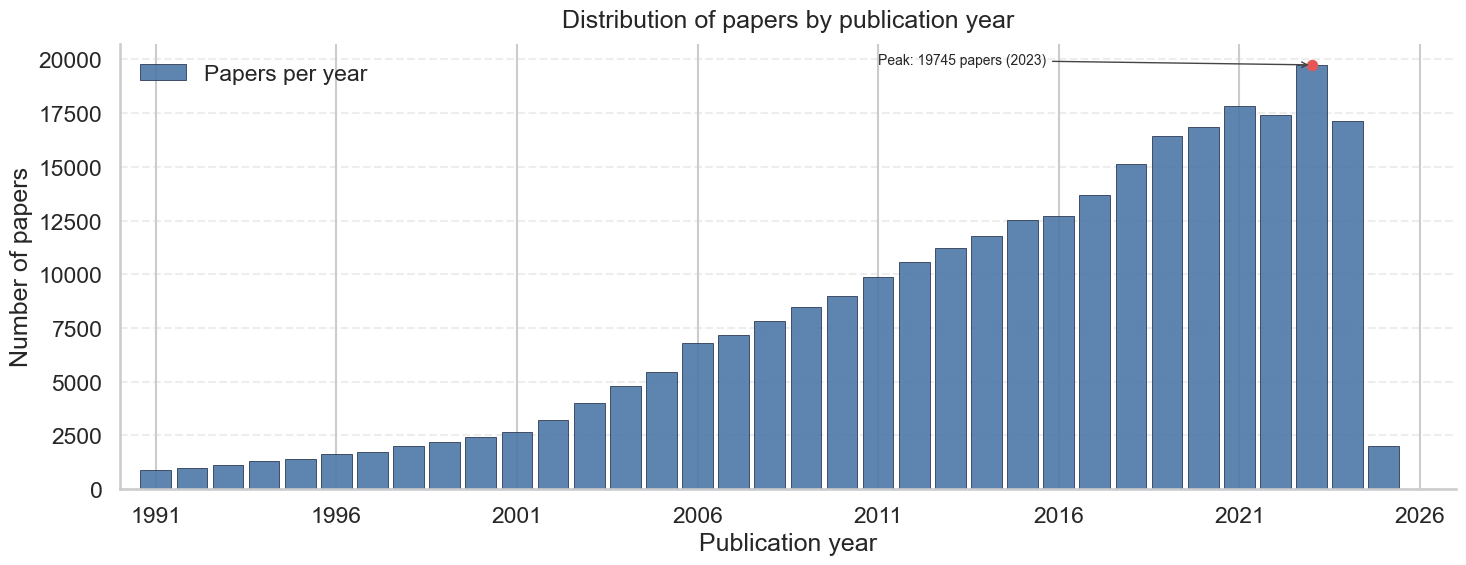

In [32]:
year_counts = (
    df["year"]
    .dropna()
    .astype(int)
    .value_counts()
    .sort_index()
)

year_counts = year_counts.reindex(
    range(year_counts.index.min(), year_counts.index.max() + 1),
    fill_value=0
)
rolling_avg = year_counts.rolling(window=5, center=True, min_periods=1).mean()

fig, ax = plt.subplots(figsize=(15, 6))
ax.bar(
    year_counts.index,
    year_counts.values,
    width=0.85,
    color="#4C78A8",
    edgecolor="#1F2A44",
    linewidth=0.6,
    alpha=0.9,
    label="Papers per year"
)

peak_year = int(year_counts.idxmax())
peak_value = int(year_counts.max())
ax.scatter([peak_year], [peak_value], color="#E45756", s=45, zorder=3)
ax.annotate(
    f"Peak: {peak_value} papers ({peak_year})",
    xy=(peak_year, peak_value),
    xytext=(peak_year - 12, peak_value + 35),
    arrowprops=dict(arrowstyle="->", color="#444444", lw=1),
    fontsize=10
)

tick_years = list(range(year_counts.index.min(), year_counts.index.max() + 1, 5))
if year_counts.index.max() not in tick_years:
    tick_years.append(year_counts.index.max())

ax.set_xticks(tick_years)
ax.set_xlim(year_counts.index.min() - 1, year_counts.index.max() + 1)
ax.set_title("Distribution of papers by publication year", pad=12)
ax.set_xlabel("Publication year")
ax.set_ylabel("Number of papers")
ax.grid(axis="y", linestyle="--", alpha=0.35)
ax.legend(frameon=False)
sns.despine(ax=ax)

plt.tight_layout()
plt.show()

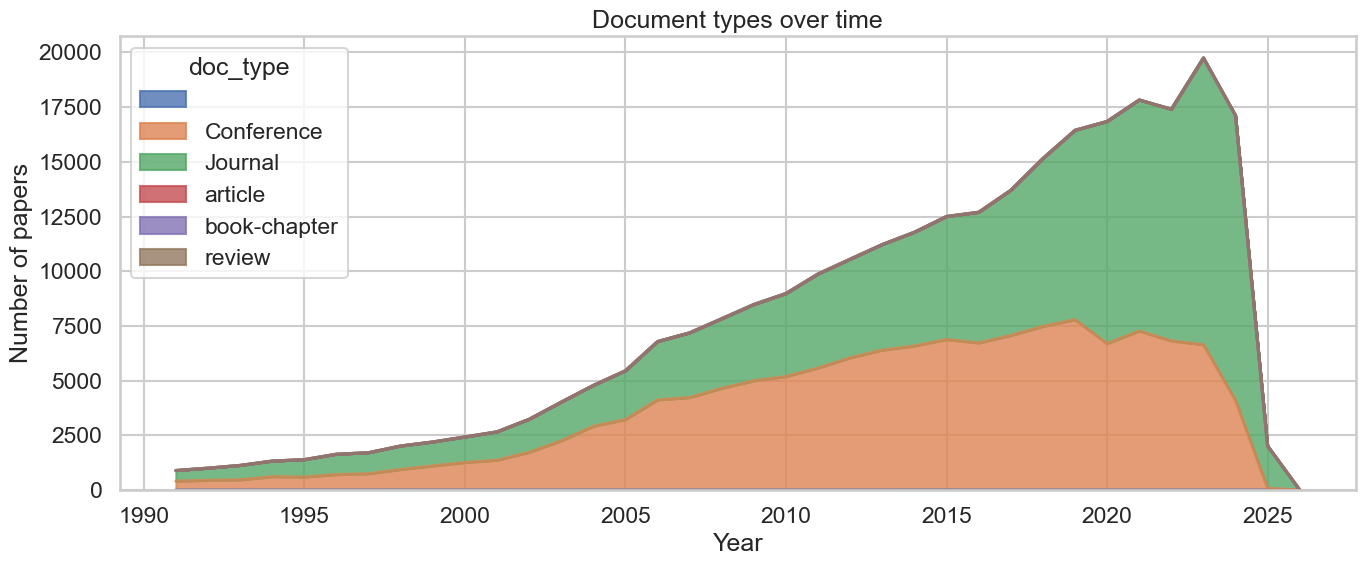

In [33]:
tmp = (
    df.dropna(subset=["year"])
      .assign(year=lambda x: x["year"].astype(int))
      .groupby(["year", "doc_type"])
      .size()
      .unstack(fill_value=0)
)

tmp.plot.area(figsize=(14, 6), alpha=0.8)
plt.title("Document types over time")
plt.xlabel("Year")
plt.ylabel("Number of papers")
plt.tight_layout()
plt.show()


plot commentati sono abbastanza inutili, in teoria qui lavoreremo già con il dataset imputato e 0 missings

In [34]:
sns.set_theme(style="whitegrid", context="talk")
plt.rcParams["figure.figsize"] = (12, 5)

def is_empty(x):
    if x is None:
        return True
    if isinstance(x, str):
        return x.strip() == ""
    if isinstance(x, (list, tuple, set, dict)):
        return len(x) == 0
    if isinstance(x, np.ndarray):
        return x.size == 0
    return pd.isna(x)

In [41]:
# cols_to_check = ["id", "title", "abstract", "year", "lang", "venue", "doc_type",
#                  "keywords", "references", "doi", "authors"]

# missing_summary = pd.DataFrame({
#     "missing_count": [df[col].apply(is_empty).sum() for col in cols_to_check],
#     "missing_pct": [df[col].apply(is_empty).mean() * 100 for col in cols_to_check]
# }, index=cols_to_check).sort_values("missing_pct", ascending=False)

# display(missing_summary)

# plt.figure(figsize=(10, 6))
# sns.barplot(
#     data=missing_summary.reset_index(),
#     x="missing_pct",
#     y="index",
#     color="#E45756"
# )
# plt.title("Missing values by column")
# plt.xlabel("Missing (%)")
# plt.ylabel("Column")
# plt.tight_layout()
# plt.show()


In [40]:
# important_cols = ["abstract", "doi", "venue", "lang", "keywords", "references"]

# heatmap_df = pd.DataFrame(index=sorted(df["year"].dropna().astype(int).unique()))

# for col in important_cols:
#     tmp = (
#         df.dropna(subset=["year"])
#           .assign(year=lambda x: x["year"].astype(int),
#                   missing=lambda x: x[col].apply(is_empty))
#           .groupby("year")["missing"]
#           .mean()
#           .mul(100)
#     )
#     heatmap_df[col] = tmp

# plt.figure(figsize=(10, 6))
# sns.heatmap(heatmap_df, cmap="Reds", annot=False)
# plt.title("Missing percentage by year and variable")
# plt.xlabel("Variable")
# plt.ylabel("Year")
# plt.tight_layout()
# plt.show()

In [39]:
# cols = ["abstract", "doi", "venue", "lang", "keywords", "references"]

# missing_flags = pd.DataFrame({
#     col: df[col].apply(is_empty).astype(int)
#     for col in cols
# })

# corr = missing_flags.corr()

# plt.figure(figsize=(8, 6))
# sns.heatmap(corr, annot=True, cmap="coolwarm", vmin=-1, vmax=1)
# plt.title("Correlation of missingness")
# plt.tight_layout()
# plt.show()


In [43]:
# important_cols = ["abstract", "doi", "venue", "lang", "keywords", "references"]

# def plot_missing_by_year(col):
#     missing_by_year = (
#         df.dropna(subset=["year"])
#           .assign(
#               year=lambda x: x["year"].astype(int),
#               missing=lambda x: x[col].apply(is_empty)
#           )
#           .groupby("year")["missing"]
#           .agg(["sum", "mean", "count"])
#           .reset_index()
#     )

#     missing_by_year["mean"] *= 100

#     fig, axes = plt.subplots(1, 2, figsize=(16, 5))

#     sns.lineplot(
#         data=missing_by_year,
#         x="year",
#         y="sum",
#         ax=axes[0],
#         marker="o"
#     )
#     axes[0].set_title(f"Missing {col} by year")
#     axes[0].set_xlabel("Year")
#     axes[0].set_ylabel("Missing count")

#     sns.lineplot(
#         data=missing_by_year,
#         x="year",
#         y="mean",
#         ax=axes[1],
#         marker="o",
#         color="#E45756"
#     )
#     axes[1].set_title(f"Missing {col} by year (%)")
#     axes[1].set_xlabel("Year")
#     axes[1].set_ylabel("Missing percentage")

#     plt.tight_layout()
#     plt.show()

# widgets.interact(plot_missing_by_year, col=important_cols)

plot per capire una prima similarità tra documenti

In [45]:
# from sklearn.feature_extraction.text import TfidfVectorizer
# from sklearn.decomposition import PCA
# import plotly.express as px

# text = (df["title"].fillna("") + " " + df["abstract"].fillna("")).fillna("")

# vectorizer = TfidfVectorizer(max_features=2000, stop_words="english")
# X = vectorizer.fit_transform(text)

# coords = PCA(n_components=2).fit_transform(X.toarray())

# plot_df = df.copy()
# plot_df["x"] = coords[:, 0]
# plot_df["y"] = coords[:, 1]

# fig = px.scatter(
#     plot_df,
#     x="x",
#     y="y",
#     color="lang",
#     hover_data=["title", "year", "venue"],
#     title="Document map"
# )
# fig.show()

## Data Quality and Normalization

qui dobbiamo normalizzare testo, DOI, venue, doc_type e nomi autore, creare flag di qualità dati, evidenziare inconsistenze utili per il task finale

In [ ]:
# legge tutto il file in un df servono circa 30gb ram
# import pandas as pd
df_clean = pd.read_parquet("data/final_dataset.parquet")

In [3]:
import re
import math
import unicodedata
from collections import defaultdict

CURRENT_YEAR = 2026
MIN_REASONABLE_YEAR = 1950

ZERO_WIDTH_PATTERN = re.compile(r"[\u200b-\u200d\ufeff]")
MULTISPACE_PATTERN = re.compile(r"\s+")
PUNCT_TO_SPACE_PATTERN = re.compile(r"[^a-z0-9]+")
DOI_PREFIX_PATTERN = re.compile(r"^(https?://(dx\.)?doi\.org/|doi:)", re.IGNORECASE)

VENUE_REPLACEMENTS = {
    "intl": "international",
    "int'l": "international",
    "conf": "conference",
    "proc": "proceedings",
    "symp": "symposium",
    "sympos": "symposium",
    "worksh": "workshop",
    "trans": "transactions",
    "j": "journal",
}

DOC_TYPE_RULES = [
    ("conference", ("conference", "proceedings", "symposium", "workshop")),
    ("journal", ("journal", "transactions", "magazine")),
    ("book-chapter", ("chapter", "book chapter")),
    ("book", ("book",)),
    ("preprint", ("preprint", "posted content")),
    ("dissertation", ("dissertation", "thesis")),
    ("report", ("report", "technical report")),
]

def is_empty(x):
    if x is None:
        return True
    if isinstance(x, float) and math.isnan(x):
        return True
    if isinstance(x, str):
        return x.strip() == ""
    if isinstance(x, np.ndarray):
        return x.size == 0
    if isinstance(x, (list, tuple, set, dict)):
        return len(x) == 0
    return False

def ensure_list(x):
    if x is None:
        return []
    if isinstance(x, np.ndarray):
        return x.tolist()
    if isinstance(x, list):
        return x
    if isinstance(x, tuple):
        return list(x)
    return []

def clean_string(x):
    if x is None:
        return ""
    if isinstance(x, float) and math.isnan(x):
        return ""
    return str(x).strip()

def normalize_text(x, lowercase=True):
    text = clean_string(x)
    if not text:
        return ""
    text = unicodedata.normalize("NFKC", text)
    text = ZERO_WIDTH_PATTERN.sub("", text)
    text = MULTISPACE_PATTERN.sub(" ", text).strip()
    return text.lower() if lowercase else text

def strip_accents(x):
    text = normalize_text(x, lowercase=True)
    if not text:
        return ""
    decomposed = unicodedata.normalize("NFKD", text)
    return "".join(ch for ch in decomposed if not unicodedata.combining(ch))

def normalize_for_key(x):
    text = strip_accents(x)
    text = PUNCT_TO_SPACE_PATTERN.sub(" ", text)
    return MULTISPACE_PATTERN.sub(" ", text).strip()

def normalize_doi(x):
    doi = normalize_text(x, lowercase=True)
    if not doi:
        return ""
    doi = DOI_PREFIX_PATTERN.sub("", doi)
    return doi.strip().rstrip("/")

def normalize_author_name(x):
    name = normalize_text(x, lowercase=False)
    if not name:
        return ""

    if "," in name:
        left, right = [part.strip() for part in name.split(",", 1)]
        if left and right:
            name = f"{right} {left}"

    name = normalize_text(name, lowercase=True)
    name = re.sub(r"[.'`]", "", name)
    name = re.sub(r"[^a-z0-9\s\-]", " ", strip_accents(name))
    return MULTISPACE_PATTERN.sub(" ", name).strip()

def normalize_venue(x):
    venue = normalize_text(x, lowercase=True)
    if not venue:
        return ""

    venue = venue.replace("&", " and ")
    venue = re.sub(r"[./,;:()\-]+", " ", venue)

    tokens = []
    for token in venue.split():
        token = token.strip(".")
        tokens.append(VENUE_REPLACEMENTS.get(token, token))

    venue = " ".join(tokens)
    venue = strip_accents(venue)
    venue = re.sub(r"\bproc of the\b", "proceedings of", venue)
    venue = re.sub(r"\bproc\b", "proceedings", venue)
    return MULTISPACE_PATTERN.sub(" ", venue).strip()

def normalize_doc_type(x):
    text = normalize_text(x, lowercase=True)
    if not text:
        return ""
    for canonical, cues in DOC_TYPE_RULES:
        if any(cue in text for cue in cues):
            return canonical
    return text

def normalize_lang(x):
    lang = normalize_text(x, lowercase=True)
    return lang[:5] if lang else ""

def contains_non_ascii(text):
    return any(ord(ch) > 127 for ch in text)


In [4]:
df_clean["title_clean"] = df_clean["title"].apply(lambda x: normalize_text(x, lowercase=False))
df_clean["title_norm"] = df_clean["title"].apply(normalize_for_key)

df_clean["abstract_clean"] = df_clean["abstract"].apply(lambda x: normalize_text(x, lowercase=False))
df_clean["abstract_norm"] = df_clean["abstract"].apply(normalize_for_key)

df_clean["venue_clean"] = df_clean["venue"].apply(lambda x: normalize_text(x, lowercase=False))
df_clean["venue_norm"] = df_clean["venue"].apply(normalize_venue)

df_clean["doc_type_clean"] = df_clean["doc_type"].apply(lambda x: normalize_text(x, lowercase=False))
df_clean["doc_type_norm"] = df_clean["doc_type"].apply(normalize_doc_type)

df_clean["doi_norm"] = df_clean["doi"].apply(normalize_doi)
df_clean["lang_norm"] = df_clean["lang"].apply(normalize_lang)
df_clean["year_clean"] = pd.to_numeric(df_clean["year"], errors="coerce")

df_clean["keywords_norm"] = df_clean["keywords"].apply(
    lambda xs: list(dict.fromkeys([normalize_for_key(x) for x in ensure_list(xs) if normalize_for_key(x)]))
)
df_clean["n_keywords"] = df_clean["keywords_norm"].apply(len)
df_clean["n_references"] = df_clean["references"].apply(lambda x: len(ensure_list(x)))


KeyboardInterrupt: 

In [ ]:
cols_preview = [
    "title", "title_norm",
    "venue", "venue_norm",
    "doc_type", "doc_type_norm",
    "doi", "doi_norm",
    "lang", "lang_norm"
]
display(df_clean[cols_preview].head(10))


In [ ]:
def extract_author_features(authors):
    authors = ensure_list(authors)

    author_names_raw = []
    author_names_norm = []
    author_names_ascii = []
    author_ids_clean = []
    author_orgs_clean = []
    author_missing_id_count = 0
    author_missing_org_count = 0
    author_non_ascii_count = 0

    pairs = []

    for author in authors:
        if not isinstance(author, dict):
            continue

        raw_name = normalize_text(author.get("name"), lowercase=False)
        norm_name = normalize_author_name(author.get("name"))
        ascii_name = normalize_for_key(author.get("name"))
        author_id = normalize_text(author.get("id"), lowercase=False)
        author_org = normalize_text(author.get("org"), lowercase=False)

        if raw_name:
            author_names_raw.append(raw_name)
        if norm_name:
            author_names_norm.append(norm_name)
        if ascii_name:
            author_names_ascii.append(ascii_name)
        if raw_name and ascii_name:
            pairs.append((raw_name, ascii_name))

        if author_id:
            author_ids_clean.append(author_id)
        else:
            author_missing_id_count += 1

        if author_org:
            author_orgs_clean.append(author_org)
        else:
            author_missing_org_count += 1

        if raw_name and contains_non_ascii(raw_name):
            author_non_ascii_count += 1

    seen = set()
    unique_pairs = []
    for pair in pairs:
        if pair not in seen:
            seen.add(pair)
            unique_pairs.append(pair)

    raw_by_ascii = defaultdict(set)
    for raw_name, ascii_name in unique_pairs:
        raw_by_ascii[ascii_name].add(raw_name)

    flag_author_name_variants_in_paper = any(len(v) > 1 for v in raw_by_ascii.values())

    return pd.Series({
        "author_names_raw": [raw for raw, _ in unique_pairs],
        "author_names_norm": list(dict.fromkeys(author_names_norm)),
        "author_names_ascii": [ascii_name for _, ascii_name in unique_pairs],
        "author_ids_clean": list(dict.fromkeys(author_ids_clean)),
        "author_orgs_clean": list(dict.fromkeys(author_orgs_clean)),
        "n_authors": len(author_names_raw),
        "author_missing_id_count": author_missing_id_count,
        "author_missing_org_count": author_missing_org_count,
        "author_non_ascii_count": author_non_ascii_count,
        "flag_author_name_variants_in_paper": flag_author_name_variants_in_paper
    })

author_features = df_clean["authors"].apply(extract_author_features)
df_clean = pd.concat([df_clean, author_features], axis=1)


In [ ]:
display(
    df_clean[
        [
            "authors",
            "author_names_raw",
            "author_names_norm",
            "author_names_ascii",
            "n_authors",
            "author_missing_id_count",
            "author_missing_org_count"
        ]
    ].head(5)
)


In [ ]:
def venue_doc_type_conflict(venue_norm, doc_type_norm):
    if not venue_norm or not doc_type_norm:
        return False

    venue_looks_conference = any(token in venue_norm for token in ["conference", "proceedings", "symposium", "workshop"])
    venue_looks_journal = any(token in venue_norm for token in ["journal", "transactions", "magazine"])

    return (
        (venue_looks_conference and doc_type_norm == "journal") or
        (venue_looks_journal and doc_type_norm == "conference")
    )

df_clean["flag_missing_title"] = df_clean["title_clean"].eq("")
df_clean["flag_missing_abstract"] = df_clean["abstract_clean"].eq("")
df_clean["flag_missing_venue"] = df_clean["venue_clean"].eq("")
df_clean["flag_missing_doc_type"] = df_clean["doc_type_clean"].eq("")
df_clean["flag_missing_doi"] = df_clean["doi_norm"].eq("")
df_clean["flag_missing_keywords"] = df_clean["n_keywords"].eq(0)
df_clean["flag_missing_references"] = df_clean["n_references"].eq(0)
df_clean["flag_missing_authors"] = df_clean["n_authors"].eq(0)

df_clean["flag_author_id_missing_any"] = df_clean["author_missing_id_count"].gt(0)
df_clean["flag_author_org_missing_any"] = df_clean["author_missing_org_count"].gt(0)
df_clean["flag_author_non_ascii_present"] = df_clean["author_non_ascii_count"].gt(0)

df_clean["flag_year_missing"] = df_clean["year_clean"].isna()
df_clean["flag_year_suspicious"] = df_clean["year_clean"].apply(
    lambda x: False if pd.isna(x) else int(x) < MIN_REASONABLE_YEAR or int(x) > CURRENT_YEAR + 1
)
df_clean["flag_doc_type_unknown"] = df_clean["doc_type_norm"].eq("")
df_clean["flag_venue_doc_type_conflict"] = [
    venue_doc_type_conflict(v, d)
    for v, d in zip(df_clean["venue_norm"], df_clean["doc_type_norm"])
]

quality_cols = [
    "flag_missing_title",
    "flag_missing_abstract",
    "flag_missing_venue",
    "flag_missing_doc_type",
    "flag_missing_doi",
    "flag_missing_keywords",
    "flag_missing_references",
    "flag_missing_authors",
    "flag_author_id_missing_any",
    "flag_author_org_missing_any",
    "flag_year_missing",
    "flag_year_suspicious",
    "flag_venue_doc_type_conflict"
]

df_clean["quality_score"] = df_clean[quality_cols].sum(axis=1).astype(int)


In [ ]:
quality_summary = pd.DataFrame({
    "count": df_clean[quality_cols].sum().astype(int),
    "pct": (df_clean[quality_cols].mean() * 100).round(2)
}).sort_values("count", ascending=False)

display(quality_summary)


In [ ]:
plot_df = quality_summary.reset_index().rename(columns={"index": "flag"})

plt.figure(figsize=(12, 7))
sns.barplot(data=plot_df, x="count", y="flag", color="#D95F02")
plt.title("Data quality flags")
plt.xlabel("Rows flagged")
plt.ylabel("")
plt.tight_layout()
plt.show()


In [ ]:
score_dist = (
    df_clean["quality_score"]
    .value_counts()
    .sort_index()
    .rename_axis("quality_score")
    .reset_index(name="count")
)

plt.figure(figsize=(10, 6))
sns.barplot(data=score_dist, x="quality_score", y="count", color="#1B9E77")
plt.title("Quality score distribution")
plt.xlabel("Quality score")
plt.ylabel("Rows")
plt.tight_layout()
plt.show()


In [ ]:
year_quality = (
    df_clean.dropna(subset=["year_clean"])
    .assign(year_clean=lambda x: x["year_clean"].astype(int))
    .groupby("year_clean")[[
        "flag_missing_abstract",
        "flag_author_org_missing_any",
        "flag_venue_doc_type_conflict"
    ]]
    .mean()
    .mul(100)
    .reset_index()
)

year_quality_long = year_quality.melt(id_vars="year_clean", var_name="issue", value_name="pct")

plt.figure(figsize=(14, 6))
sns.lineplot(data=year_quality_long, x="year_clean", y="pct", hue="issue", marker="o")
plt.title("Quality issues by year")
plt.xlabel("Year")
plt.ylabel("Rows flagged (%)")
plt.tight_layout()
plt.show()


In [ ]:
author_alias_rows = []

for _, row in df_clean.iterrows():
    raw_names = row["author_names_raw"]
    ascii_names = row["author_names_ascii"]

    for raw_name, ascii_name in zip(raw_names, ascii_names):
        author_alias_rows.append({
            "author_ascii": ascii_name,
            "author_raw": raw_name
        })

author_alias_df = pd.DataFrame(author_alias_rows)

author_alias_summary = (
    author_alias_df.groupby("author_ascii")
    .agg(
        n_variants=("author_raw", "nunique"),
        examples=("author_raw", lambda x: " | ".join(sorted(set(list(x)[:10]))[:5]))
    )
    .reset_index()
    .sort_values(["n_variants", "author_ascii"], ascending=[False, True])
)

author_alias_summary = author_alias_summary[author_alias_summary["n_variants"] > 1]
display(author_alias_summary.head(20))


In [ ]:
top_author_alias = author_alias_summary.head(15).sort_values("n_variants", ascending=True)

plt.figure(figsize=(12, 7))
sns.barplot(data=top_author_alias, x="n_variants", y="author_ascii", color="#7570B3")
plt.title("Author aliases collapsed by normalization")
plt.xlabel("Distinct raw spellings")
plt.ylabel("Author normalized key")
plt.tight_layout()
plt.show()


In [ ]:
venue_alias_df = (
    df_clean.loc[df_clean["venue_norm"] != "", ["venue_clean", "venue_norm"]]
    .drop_duplicates()
)

venue_alias_summary = (
    venue_alias_df.groupby("venue_norm")
    .agg(
        n_variants=("venue_clean", "nunique"),
        examples=("venue_clean", lambda x: " | ".join(sorted(set(list(x)[:10]))[:5]))
    )
    .reset_index()
    .sort_values(["n_variants", "venue_norm"], ascending=[False, True])
)

venue_alias_summary = venue_alias_summary[venue_alias_summary["n_variants"] > 1]
display(venue_alias_summary.head(20))


In [ ]:
top_venue_alias = venue_alias_summary.head(15).sort_values("n_variants", ascending=True)

plt.figure(figsize=(12, 7))
sns.barplot(data=top_venue_alias, x="n_variants", y="venue_norm", color="#E7298A")
plt.title("Venue aliases collapsed by normalization")
plt.xlabel("Distinct raw spellings")
plt.ylabel("Venue normalized key")
plt.tight_layout()
plt.show()


In [ ]:
conflict_examples = df_clean.loc[
    df_clean["flag_venue_doc_type_conflict"],
    ["id", "title", "year_clean", "venue_clean", "venue_norm", "doc_type_clean", "doc_type_norm"]
].copy()

print(f"Numero di conflitti venue/doc_type: {len(conflict_examples):,}")
display(conflict_examples.head(20))


In [ ]:
author_problem_examples = df_clean.loc[
    df_clean["flag_author_id_missing_any"] | df_clean["flag_author_org_missing_any"] | df_clean["flag_author_name_variants_in_paper"],
    [
        "id",
        "title",
        "year_clean",
        "author_names_raw",
        "author_names_norm",
        "author_ids_clean",
        "author_orgs_clean",
        "author_missing_id_count",
        "author_missing_org_count",
        "flag_author_name_variants_in_paper"
    ]
].copy()

display(author_problem_examples.head(20))


In [ ]:
cols_for_next_steps = [
    "id",
    "title",
    "title_norm",
    "abstract",
    "abstract_norm",
    "keywords",
    "keywords_norm",
    "year",
    "year_clean",
    "authors",
    "author_names_raw",
    "author_names_norm",
    "author_names_ascii",
    "author_ids_clean",
    "author_orgs_clean",
    "n_authors",
    "references",
    "n_references",
    "lang",
    "lang_norm",
    "doi",
    "doi_norm",
    "venue",
    "venue_clean",
    "venue_norm",
    "doc_type",
    "doc_type_clean",
    "doc_type_norm",
    "n_keywords",
    "quality_score"
] + quality_cols

df_model_base = df_clean[cols_for_next_steps].copy()
print(df_model_base.shape)
display(df_model_base.head(3))